# Grayscale Fragmentation Analysis

This notebook demonstrates the `frag_gray()` function, which performs fragmentation
analysis on continuous-value rasters where pixel values represent foreground intensity
from 0 to 100 (e.g., tree cover density).

We will:
1. Load and inspect the Copernicus Tree Cover Density 2023 map of Sardinia
2. Compute grayscale FAD with different foreground thresholds
3. Compare FAD, FAC, and FED methods
4. Visualise the results

**Study area**: Sardinia, Italy — 100 m resolution (upscaled from 10 m Copernicus TCD 2023)

## 1. Import Libraries

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import rasterio
from IPython.display import Image, display

In [2]:
import pyguidos as pg
from pyguidos import utils
print(f"pyGuidos version: {pg.__version__}")

pyGuidos version: 2.5.2


## 2. Define Paths and Inspect the Input

In [3]:
# Input: Tree Cover Density 2023 - Sardinia (100m)
tcd_tiff = pg.DATA_DIR / "TCD2023_sardinia.tif"
print(f"\u2713  {tcd_tiff.name}" if tcd_tiff.exists() else f"\u2717  NOT FOUND: {tcd_tiff}")

✓  TCD2023_sardinia.tif


In [6]:
# Output directory
CONFIG_PATH = pg.PROJECT_ROOT / ".notebook_config"

if CONFIG_PATH.exists():
    OUT_DIR = Path(CONFIG_PATH.read_text(encoding="utf-8").strip())
    print(f"Loaded existing workspace: {OUT_DIR}")
else:
    OUT_DIR = pg.PROJECT_ROOT / "output"
    print(f"Using default workspace: {OUT_DIR}")

OUT_DIR.mkdir(parents=True, exist_ok=True)

Loaded existing workspace: C:\Users\caudugi\Documents\Work\z.tmp\pyguidos_examples


In [7]:
# Inspect metadata
info = utils.get_raster_info(tcd_tiff)

print("="*50)
print("Tree Cover Density 2023 — Sardinia")
print("="*50)
print(f"  Size      : {info['rows']} rows x {info['cols']} cols")
print(f"  Resolution: {info['resX']} x {info['resY']} m")
print(f"  EPSG      : {info['epsg']}")
print(f"  Dtype     : {info['dtype']}")

Tree Cover Density 2023 — Sardinia
  Size      : 2750 rows x 1490 cols
  Resolution: 100.0 x 100.0 m
  EPSG      : 3035
  Dtype     : uint8


In [8]:
# Read and inspect pixel value distribution
with rasterio.open(tcd_tiff) as src:
    tcd_data = src.read(1)

pxl_freq = utils.get_pxl_freq(tcd_data)

# Count by category
non_fg = pxl_freq.get(0, 0)
fg_pixels = sum(count for val, count in pxl_freq.items() if 1 <= val <= 100)
nodata = sum(count for val, count in pxl_freq.items() if val > 100)
total = info['rows'] * info['cols']

print(f"\nPixel distribution:")
print(f"  Non-foreground (0)   : {non_fg:>10} px ({non_fg/total*100:.1f}%)")
print(f"  Foreground (1-100)   : {fg_pixels:>10} px ({fg_pixels/total*100:.1f}%)")
print(f"  NoData (>100)        : {nodata:>10} px ({nodata/total*100:.1f}%)")
print(f"  Total                : {total:>10} px")


Pixel distribution:
  Non-foreground (0)   :     968787 px (23.6%)
  Foreground (1-100)   :    1496616 px (36.5%)
  NoData (>100)        :    1632097 px (39.8%)
  Total                :    4097500 px


## 3. Visualise the Input Map

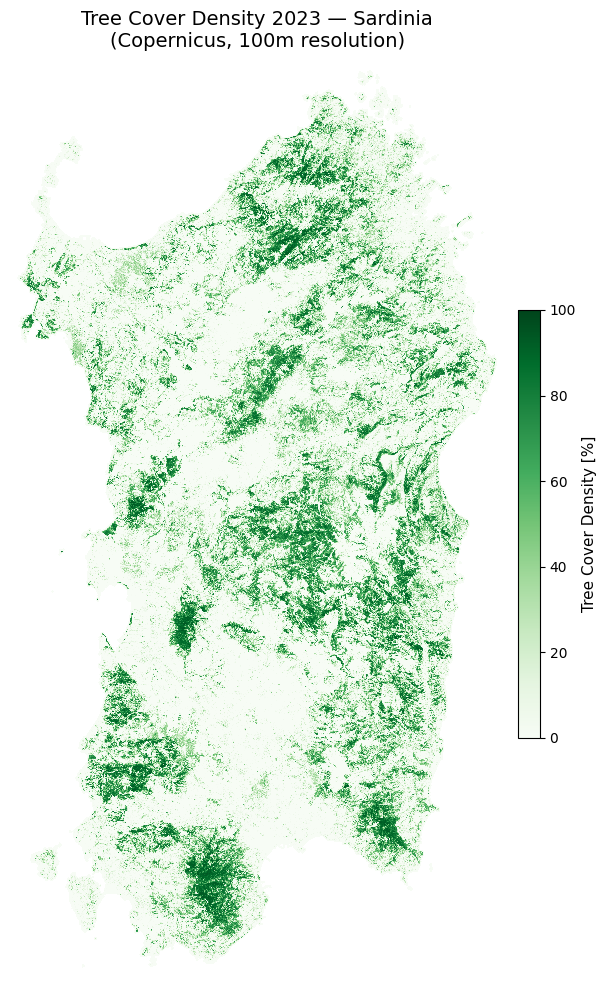

In [9]:
# Display the TCD map
display_data = tcd_data.astype(np.float32)
display_data[tcd_data > 100] = np.nan  # Mask NoData

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(display_data, cmap='Greens', vmin=0, vmax=100, interpolation='none')
ax.set_title('Tree Cover Density 2023 — Sardinia\n(Copernicus, 100m resolution)', fontsize=14, pad=15)
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Tree Cover Density [%]', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Grayscale FAD with Different Thresholds

The `for_threshold` parameter determines which pixels are considered foreground.
Pixels with values below the threshold are treated as non-foreground during computation.

- `for_threshold=1`: all tree cover values (1-100%) are considered forest
- `for_threshold=30`: only pixels with ≥30% tree cover are considered forest
- `for_threshold=50`: only pixels with ≥50% tree cover are considered forest

In [10]:
print("Computing grayscale FAD with threshold=1 (all tree cover)...")
result_t1 = pg.frag_gray(
    in_tiff=tcd_tiff,
    method='FAD',
    window_size=27,
    for_threshold=1,
    outdir=OUT_DIR,
    verb=True
)
print("Done.\n")

Computing grayscale FAD with threshold=1 (all tree cover)...
[   START   ]  Verifying input raster...
[    OK     ]  Input raster verified.
[   START   ]  Computing Grayscale Fragmentation...
[    OK     ]  Grayscale Fragmentation computed.
[   START   ]  Generating statistics...
[    OK     ]  Statistics complete and files saved.

>>> Grayscale Fragmentation task finished in 2.06 seconds
Done.



In [11]:
print("Computing grayscale FAD with threshold=30...")
result_t30 = pg.frag_gray(
    in_tiff=tcd_tiff,
    method='FAD',
    window_size=27,
    for_threshold=30,
    outdir=OUT_DIR,
    verb=True
)
print("Done.")

Computing grayscale FAD with threshold=30...
[   START   ]  Verifying input raster...
[    OK     ]  Input raster verified.
[   START   ]  Computing Grayscale Fragmentation...
[    OK     ]  Grayscale Fragmentation computed.
[   START   ]  Generating statistics...
[    OK     ]  Statistics complete and files saved.

>>> Grayscale Fragmentation task finished in 0.43 seconds
Done.


In [12]:
print("Computing grayscale FAD with threshold=50...")
result_t50 = pg.frag_gray(
    in_tiff=tcd_tiff,
    method='FAD',
    window_size=27,
    for_threshold=50,
    outdir=OUT_DIR,
    verb=True
)
print("Done.")

Computing grayscale FAD with threshold=50...
[   START   ]  Verifying input raster...
[    OK     ]  Input raster verified.
[   START   ]  Computing Grayscale Fragmentation...
[    OK     ]  Grayscale Fragmentation computed.
[   START   ]  Generating statistics...
[    OK     ]  Statistics complete and files saved.

>>> Grayscale Fragmentation task finished in 0.29 seconds
Done.


In [13]:
# Compare foreground pixel counts
print("Effect of for_threshold on foreground classification:")
print(f"  Threshold=1  : Input FG = {result_t1['input stats']['in foreground pxl']:>10}, " +
      f"Output FG = {result_t1['input stats']['out foreground pxl']:>10}")
print(f"  Threshold=30 : Input FG = {result_t30['input stats']['in foreground pxl']:>10}, " + 
      f"Output FG = {result_t30['input stats']['out foreground pxl']:>10}")
print(f"  Threshold=50 : Input FG = {result_t50['input stats']['in foreground pxl']:>10}, " + 
      f"Output FG = {result_t30['input stats']['out foreground pxl']:>10}")

Effect of for_threshold on foreground classification:
  Threshold=1  : Input FG =    1496616, Output FG =    1496616
  Threshold=30 : Input FG =    1496616, Output FG =     629572
  Threshold=50 : Input FG =    1496616, Output FG =     629572


## 5. Visualise FAD Results

In [14]:
def gtb_colormap(tiff_path):
    """Reads the embedded GTB colormap from a pyGuidos output GeoTIFF
    and returns the data, a matplotlib ListedColormap, Normalize, 
    and a ScalarMappable for a clean 0-100 colorbar."""
    from matplotlib.cm import ScalarMappable
    
    with rasterio.open(tiff_path) as src:
        data = src.read(1)
        cmap_dict = src.colormap(1)
    
    # Full 0-255 colormap for rendering
    colors = np.zeros((256, 4), dtype=np.float32)
    for val, rgba in cmap_dict.items():
        if 0 <= val < 256:
            colors[val] = [c / 255.0 for c in rgba]
    cmap = ListedColormap(colors)
    norm = plt.Normalize(vmin=0, vmax=255)
    
    # 0-100 only colorbar mappable
    cbar_colors = [colors[i] for i in range(101)]
    cbar_cmap = ListedColormap(cbar_colors)
    cbar_norm = plt.Normalize(vmin=0, vmax=100)
    cbar_sm = ScalarMappable(cmap=cbar_cmap, norm=cbar_norm)
    
    return data, cmap, norm, cbar_sm

In [17]:
result_t1['output paths']['path tif']

'C:\\Users\\caudugi\\Documents\\Work\\z.tmp\\pyguidos_examples\\TCD2023_sardinia_frag_gray_fad_27.tif'

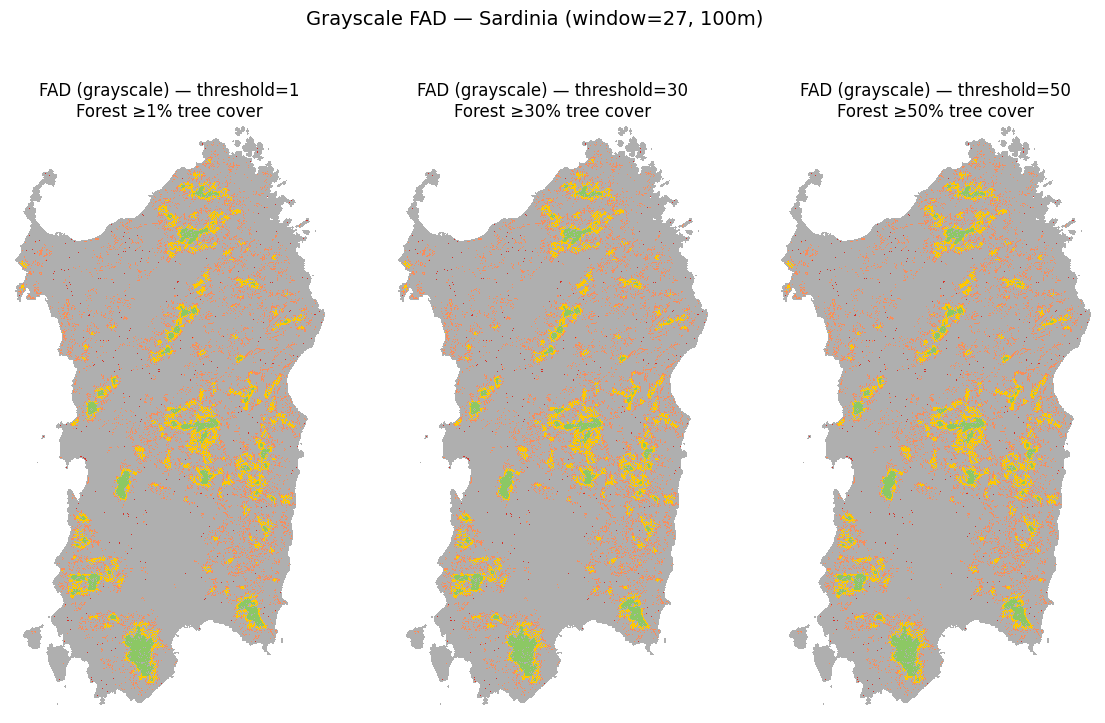

In [16]:
# Visualise island-level fragmentation
fad_t1, cmap_t1, norm_t1, cbar_sm_t1 = gtb_colormap(result_t1['output paths']['path tif'])
fad_t30, cmap_t30, norm_t30, cbar_sm_t30 = gtb_colormap(result_t30['output paths']['path tif'])
fad_t50, cmap_t50, norm_t50, cbar_sm_t50 = gtb_colormap(result_t50['output paths']['path tif'])

fig, axes = plt.subplots(1, 3, figsize=(14, 9))

im1 = axes[0].imshow(fad_t1, cmap=cmap_t1, norm=norm_t1, interpolation='none')
axes[0].set_title('FAD (grayscale) — threshold=1\nForest \u22651% tree cover', fontsize=12)
axes[0].axis('off')

im2 = axes[1].imshow(fad_t30, cmap=cmap_t30, norm=norm_t30, interpolation='none')
axes[1].set_title('FAD (grayscale) — threshold=30\nForest \u226530% tree cover', fontsize=12)
axes[1].axis('off')

im3 = axes[2].imshow(fad_t50, cmap=cmap_t50, norm=norm_t50, interpolation='none')
axes[2].set_title('FAD (grayscale) — threshold=50\nForest \u226550% tree cover', fontsize=12)
axes[2].axis('off')

fig.suptitle('Grayscale FAD — Sardinia (window=27, 100m)', fontsize=14, y=0.95)
plt.show()

## 6. Compare FAD, FAC, and FED Methods

Using threshold=30 and window=27 for all three methods:

In [ ]:
print("Computing grayscale FAC (4-connected)...")
result_fac = pg.frag_gray(
    in_tiff=tcd_tiff,
    method='FAC',
    window_size=27,
    for_threshold=30,
    connectivity=4,
    outdir=OUT_DIR,
    verb=True
)
print("Done.\n")

print("Computing grayscale FED (4-connected)...")
result_fed = pg.frag_gray(
    in_tiff=tcd_tiff,
    method='FED',
    window_size=27,
    for_threshold=30,
    connectivity=4,
    outdir=OUT_DIR,
    verb=True
)
print("Done.")

In [ ]:
# Compare connectivity indices
print("="*60)
print("Method Comparison (window=27, threshold=30)")
print("="*60)
print(f"{'Method':<8} {'FAD_av':>10} {'AVcon':>10}")
print("-"*30)
print(f"{'FAD':<8} {result_t1['output stats']['fad_av']:>10.2f} {result_t1['output stats']['avcon']:>10.2f}")
print(f"{'FAC':<8} {result_fac['output stats']['fad_av']:>10.2f} {result_fac['output stats']['avcon']:>10.2f}")
print(f"{'FED':<8} {result_fed['output stats']['fad_av']:>10.2f} {result_fed['output stats']['avcon']:>10.2f}")

## 7. Display Auto-generated Histograms

In [ ]:
# FAD histogram
png_path = Path(result_t30['output paths']['path png'])
if png_path.exists():
    print("FAD (threshold=30):")
    display(Image(filename=str(png_path), width=500))

In [ ]:
# FAC histogram
png_path = Path(result_fac['output paths']['path png'])
if png_path.exists():
    print("FAD (threshold=30):")
    display(Image(filename=str(png_path), width=500))

In [ ]:
# FED histogram
png_path = Path(result_fed['output paths']['path png'])
if png_path.exists():
    print("FED (threshold=30):")
    display(Image(filename=str(png_path), width=500))

## 8. Standalone Statistics with frag_gray_stats()

You can recompute statistics from an existing output GeoTIFF without rerunning the analysis:

In [ ]:
# Recompute stats from existing output, providing source for input counts
existing_tiff = result_t1['output paths']['path tif']

stats = pg.frag_gray_stats(
    frag_tiff=existing_tiff,
    stat_files=False,
    source_tiff=str(tcd_tiff)
)

print("Statistics recovered from existing output:")
print(f"  Input FG pixels  : {stats['input stats']['in foreground pxl']}")
print(f"  Output FG pixels : {stats['input stats']['out foreground pxl']}")
print(f"  FAD_av           : {stats['output stats']['fad_av']:.2f}")
print(f"  AVcon            : {stats['output stats']['avcon']:.2f}")

## 9. Summary

In this notebook we have:

- Loaded and inspected a continuous Tree Cover Density map (Copernicus TCD 2023)
- Computed grayscale FAD with different foreground thresholds, showing how
  `for_threshold` controls which pixels are considered forest
- Compared the three grayscale methods (FAD, FAC, FED) on the same input
- Visualised the spatial results and auto-generated histograms
- Demonstrated `frag_gray_stats()` for standalone statistics recovery

The grayscale fragmentation analysis extends the binary approach by preserving
the continuous nature of the input data, providing a more nuanced assessment
of landscape connectivity where tree cover varies gradually rather than in
binary forest/non-forest categories.